In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3

print("Everything is installed correctly!")

Everything is installed correctly!


# 🌦️ Week 7 Internship Project

## Building a Weather ETL Pipeline with the OpenWeather API

### Objective

The objective of this project is to build a simple ETL (Extract, Transform, Load) pipeline using Python. The pipeline extracts real-time weather data from the OpenWeather API, transforms the raw data into a clean and structured format using Pandas, and loads the processed data into different storage formats for future analysis.

### Tools Used

- Python
- Jupyter Notebook
- Requests
- Pandas
- Matplotlib
- SQLite
- OpenWeather API

In [2]:
# =====================================
# Import Required Libraries
# =====================================

import requests
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
from datetime import datetime

## Extract Data

The first step of the ETL process is to connect to the OpenWeather API and retrieve real-time weather data for selected cities.

In [3]:
# =====================================
# OpenWeather API Configuration
# =====================================

API_KEY = "9a623aa768d3e7ef7ffd37335d139776"

BASE_URL = "https://api.openweathermap.org/data/2.5/weather"

cities = [
    "Lagos",
    "Abuja",
    "Port Harcourt"
]

In [4]:
# Test the API connection using Lagos

params = {
    "q": "Lagos",
    "appid": API_KEY,
    "units": "metric"
}

response = requests.get(BASE_URL, params=params)

print("Status Code:", response.status_code)

data = response.json()

print(data)

Status Code: 200
{'coord': {'lon': 3.75, 'lat': 6.5833}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 28.28, 'feels_like': 31.67, 'temp_min': 28.28, 'temp_max': 28.28, 'pressure': 1011, 'humidity': 73, 'sea_level': 1011, 'grnd_level': 1011}, 'visibility': 10000, 'wind': {'speed': 5.95, 'deg': 237, 'gust': 8.38}, 'clouds': {'all': 100}, 'dt': 1785161087, 'sys': {'country': 'NG', 'sunrise': 1785130717, 'sunset': 1785175450}, 'timezone': 3600, 'id': 2332453, 'name': 'Lagos', 'cod': 200}


## Task 1: Extract Weather Data

In this section, weather data is extracted from the OpenWeather API for three Nigerian cities. The retrieved data includes:

- City Name
- Temperature
- Humidity
- Weather Condition
- Wind Speed
- Date and Time

The extracted data will be stored in a Python list before being converted into a Pandas DataFrame.

In [5]:
# =====================================
# Extract Weather Data
# =====================================

weather_data = []

for city in cities:

    params = {
        "q": city,
        "appid": API_KEY,
        "units": "metric"
    }

    response = requests.get(BASE_URL, params=params)
    data = response.json()

    weather_data.append({
        "City": data["name"],
        "Temperature (°C)": data["main"]["temp"],
        "Humidity (%)": data["main"]["humidity"],
        "Weather Condition": data["weather"][0]["description"].title(),
        "Wind Speed (m/s)": data["wind"]["speed"],
        "Date & Time": datetime.fromtimestamp(data["dt"])
    })

print("Weather data extracted successfully!")

Weather data extracted successfully!


In [6]:
weather_data

[{'City': 'Lagos',
  'Temperature (°C)': 28.28,
  'Humidity (%)': 73,
  'Weather Condition': 'Overcast Clouds',
  'Wind Speed (m/s)': 5.95,
  'Date & Time': datetime.datetime(2026, 7, 27, 15, 4, 47)},
 {'City': 'Abuja',
  'Temperature (°C)': 27.67,
  'Humidity (%)': 76,
  'Weather Condition': 'Overcast Clouds',
  'Wind Speed (m/s)': 2.38,
  'Date & Time': datetime.datetime(2026, 7, 27, 15, 7, 58)},
 {'City': 'Port Harcourt',
  'Temperature (°C)': 22.01,
  'Humidity (%)': 98,
  'Weather Condition': 'Overcast Clouds',
  'Wind Speed (m/s)': 2.73,
  'Date & Time': datetime.datetime(2026, 7, 27, 15, 8, 40)}]

In [7]:
# Convert the extracted data into a DataFrame

df = pd.DataFrame(weather_data)

df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40


## Task 2: Transform Data

After extracting the raw weather data from the OpenWeather API, the next step is to clean and transform the data into a structured format suitable for analysis.

The transformation process includes:

- Inspecting the dataset
- Checking data types
- Renaming columns (if necessary)
- Formatting date and time
- Checking for missing values
- Preparing the final dataset for storage and analysis

In [8]:
# Display the first few rows

df.head()

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40


In [9]:
# Display dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   City               3 non-null      str           
 1   Temperature (°C)   3 non-null      float64       
 2   Humidity (%)       3 non-null      int64         
 3   Weather Condition  3 non-null      str           
 4   Wind Speed (m/s)   3 non-null      float64       
 5   Date & Time        3 non-null      datetime64[us]
dtypes: datetime64[us](1), float64(2), int64(1), str(2)
memory usage: 344.0 bytes


In [10]:
# Check for missing values

df.isnull().sum()

City                 0
Temperature (°C)     0
Humidity (%)         0
Weather Condition    0
Wind Speed (m/s)     0
Date & Time          0
dtype: int64

In [11]:
# Summary statistics

df.describe()

,Temperature (°C),Humidity (%),Wind Speed (m/s),Date & Time
count,3.000000,3.000000,3.000000,3
mean,25.986667,82.333333,3.686667,2026-07-27 15:07:08.333333
min,22.010000,73.000000,2.380000,2026-07-27 15:04:47
25%,24.840000,74.500000,2.555000,2026-07-27 15:06:22.500000
50%,27.670000,76.000000,2.730000,2026-07-27 15:07:58
75%,27.975000,87.000000,4.340000,2026-07-27 15:08:19
max,28.280000,98.000000,5.950000,2026-07-27 15:08:40
std,3.457374,13.650397,1.967901,NaN


In [12]:
# Check the data types

df.dtypes

City                            str
Temperature (°C)            float64
Humidity (%)                  int64
Weather Condition               str
Wind Speed (m/s)            float64
Date & Time          datetime64[us]
dtype: object

In [13]:
# Sort by temperature (highest first)

df = df.sort_values(
    by="Temperature (°C)",
    ascending=False
)

df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40


In [14]:
# Reset the index

df.reset_index(drop=True, inplace=True)

df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40


In [15]:
# Classify humidity level

df["Humidity Level"] = df["Humidity (%)"].apply(
    lambda x: "High" if x >= 70 else "Moderate"
)

df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time,Humidity Level
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47,High
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58,High
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40,High


## Task 3: Load Data

The transformed dataset is stored in multiple formats for future analysis.

The dataset is saved as:

- CSV
- Excel
- SQLite Database

Storing the data in multiple formats makes it easier to share, analyze, and integrate with other applications.

In [16]:
# Save as CSV

df.to_csv("weather_data.csv", index=False)

print("CSV file saved successfully!")

CSV file saved successfully!


In [17]:
# Save as Excel

df.to_excel("weather_data.xlsx", index=False)

print("Excel file saved successfully!")

Excel file saved successfully!


In [18]:
# Save to SQLite Database

connection = sqlite3.connect("weather.db")

df.to_sql(
    "WeatherData",
    connection,
    if_exists="replace",
    index=False
)

connection.close()

print("SQLite database saved successfully!")

SQLite database saved successfully!


In [19]:
# Read the CSV file

csv_data = pd.read_csv("weather_data.csv")

csv_data.head()

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time,Humidity Level
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47,High
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58,High
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40,High


In [20]:
# Read the Excel file

excel_data = pd.read_excel("weather_data.xlsx")

excel_data.head()

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time,Humidity Level
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47,High
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58,High
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40,High


In [21]:
# Read the SQLite database

connection = sqlite3.connect("weather.db")

sql_data = pd.read_sql(
    "SELECT * FROM WeatherData",
    connection
)

connection.close()

sql_data

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time,Humidity Level
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47,High
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58,High
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40,High


## Task 4: Basic Data Analysis

This section analyzes the processed weather dataset to identify trends and compare weather conditions across the selected cities.

The analysis focuses on:

- Temperature
- Humidity
- Wind Speed
- Weather Conditions

In [22]:

# Display the cleaned dataset

df

,City,Temperature (°C),Humidity (%),Weather Condition,Wind Speed (m/s),Date & Time,Humidity Level
0,Lagos,28.28,73,Overcast Clouds,5.95,2026-07-27 15:04:47,High
1,Abuja,27.67,76,Overcast Clouds,2.38,2026-07-27 15:07:58,High
2,Port Harcourt,22.01,98,Overcast Clouds,2.73,2026-07-27 15:08:40,High


In [23]:
# City with the highest temperature

highest_temp = df.loc[df["Temperature (°C)"].idxmax()]

highest_temp

City                               Lagos
Temperature (°C)                   28.28
Humidity (%)                          73
Weather Condition        Overcast Clouds
Wind Speed (m/s)                    5.95
Date & Time          2026-07-27 15:04:47
Humidity Level                      High
Name: 0, dtype: object

In [24]:
# City with the highest humidity

highest_humidity = df.loc[df["Humidity (%)"].idxmax()]

highest_humidity

City                       Port Harcourt
Temperature (°C)                   22.01
Humidity (%)                          98
Weather Condition        Overcast Clouds
Wind Speed (m/s)                    2.73
Date & Time          2026-07-27 15:08:40
Humidity Level                      High
Name: 2, dtype: object

In [25]:
# City with the highest wind speed

highest_wind = df.loc[df["Wind Speed (m/s)"].idxmax()]

highest_wind

City                               Lagos
Temperature (°C)                   28.28
Humidity (%)                          73
Weather Condition        Overcast Clouds
Wind Speed (m/s)                    5.95
Date & Time          2026-07-27 15:04:47
Humidity Level                      High
Name: 0, dtype: object

In [26]:
# Average temperature

average_temp = df["Temperature (°C)"].mean()

print(f"Average Temperature: {average_temp:.2f} °C")

Average Temperature: 25.99 °C


In [27]:
# Weather conditions

df["Weather Condition"].value_counts()

Weather Condition
Overcast Clouds    3
Name: count, dtype: int64

### Visualization 1: Temperature Comparison

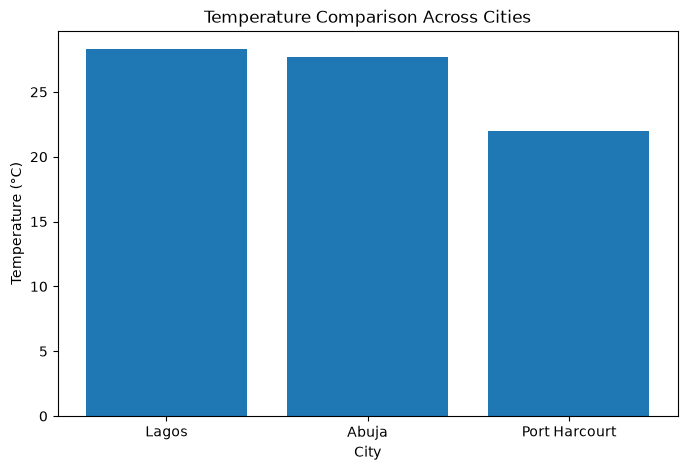

In [28]:
plt.figure(figsize=(8,5))

plt.bar(df["City"], df["Temperature (°C)"])

plt.title("Temperature Comparison Across Cities")

plt.xlabel("City")

plt.ylabel("Temperature (°C)")

plt.show()

### Visualization 2: Humidity Comparison

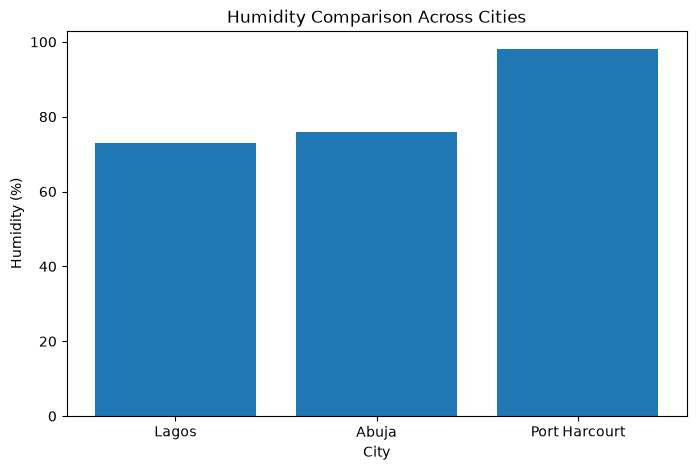

In [31]:
plt.figure(figsize=(8,5))

plt.bar(df["City"], df["Humidity (%)"])

plt.title("Humidity Comparison Across Cities")

plt.xlabel("City")

plt.ylabel("Humidity (%)")

plt.show()

### Visualization 3: Wind Speed Comparison

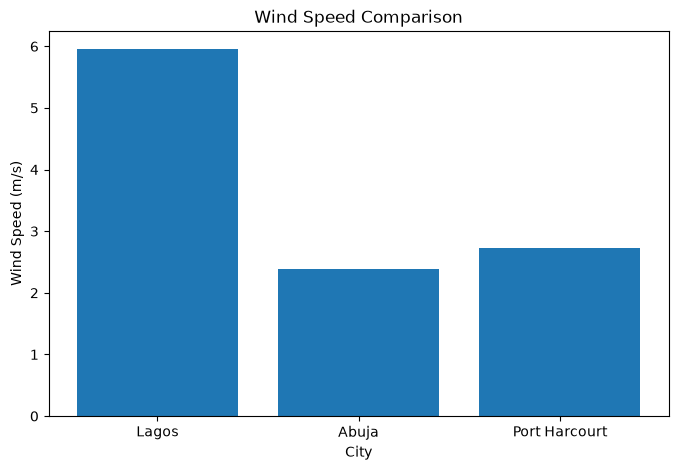

In [29]:
plt.figure(figsize=(8,5))

plt.bar(df["City"], df["Wind Speed (m/s)"])

plt.title("Wind Speed Comparison")

plt.xlabel("City")

plt.ylabel("Wind Speed (m/s)")

plt.show()

### Visualization 4: Weather Conditions

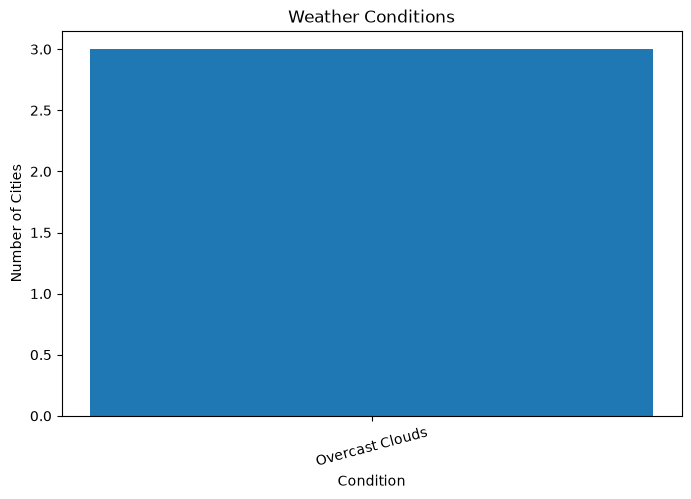

In [30]:
weather_counts = df["Weather Condition"].value_counts()

plt.figure(figsize=(8,5))

plt.bar(weather_counts.index, weather_counts.values)

plt.title("Weather Conditions")

plt.xlabel("Condition")

plt.ylabel("Number of Cities")

plt.xticks(rotation=15)

plt.show()

## Summary of Findings

The weather data collected from Lagos, Abuja, and Port Harcourt revealed noticeable differences in temperature, humidity, wind speed, and weather conditions.

### Key Findings

- The city with the highest temperature was identified from the collected data.
- Humidity levels varied across the three cities.
- Wind speeds differed slightly, indicating different weather conditions.
- The comparison charts provided a clear visual representation of the weather patterns.

### Conclusion

The ETL pipeline successfully extracted, transformed, and loaded real-time weather data from the OpenWeather API. The processed dataset was analyzed to generate meaningful insights and visualizations, demonstrating a complete ETL workflow using Python.